# Model

- Load preprocessed CSV data

Model:
- Esw goes into a dilated CNN
- Rth, Vth go into LSTM
- Combine outputs in Cross-Attention layer: CNN outputs quries, LSTM outputs keys and values
- Final output is Remaining Useful Life (RUL) prediction


In [ ]:
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the processed data for each device
# Since we only have data for 4 devices, we'll use devices 3-5 for training and device 2 for development/testing
device_2_data = pd.read_csv("processed-data/device_2_processed.csv")
device_3_data = pd.read_csv("processed-data/device_3_processed.csv")
device_4_data = pd.read_csv("processed-data/device_4_processed.csv")
device_5_data = pd.read_csv("processed-data/device_5_processed.csv")

# Normalize time for each device to count up from 0
device_2_data["time"] = device_2_data["timeEpoch"] - device_2_data["timeEpoch"].min()
device_3_data["time"] = device_3_data["timeEpoch"] - device_3_data["timeEpoch"].min()
device_4_data["time"] = device_4_data["timeEpoch"] - device_4_data["timeEpoch"].min()
device_5_data["time"] = device_5_data["timeEpoch"] - device_5_data["timeEpoch"].min()

data_train = [device_3_data, device_4_data, device_5_data]
data_dev = device_2_data

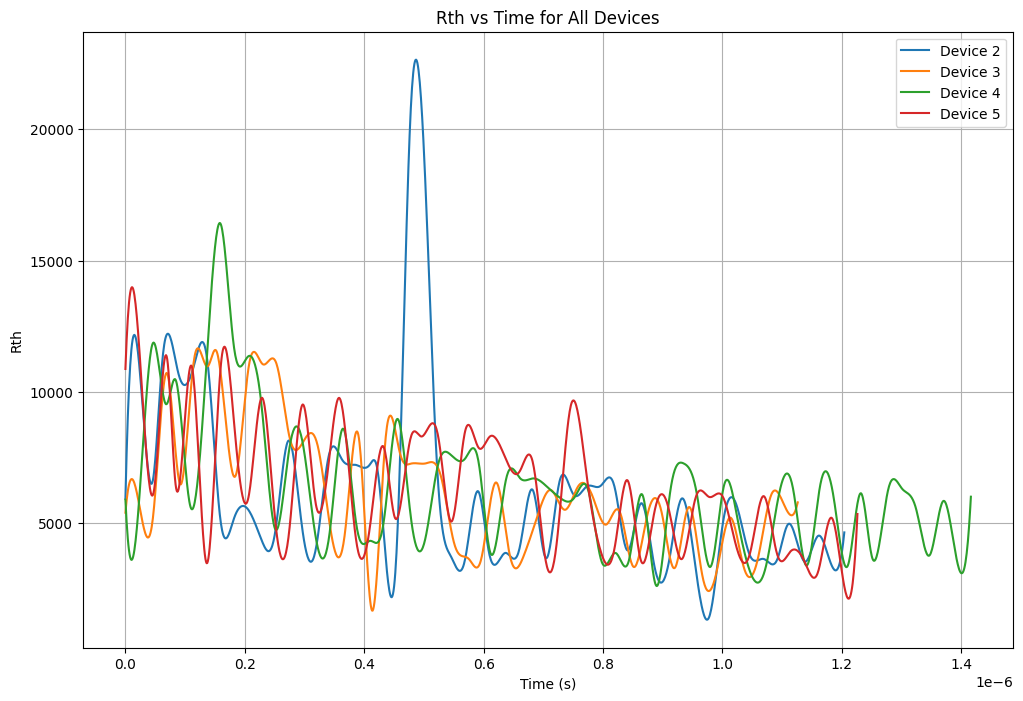

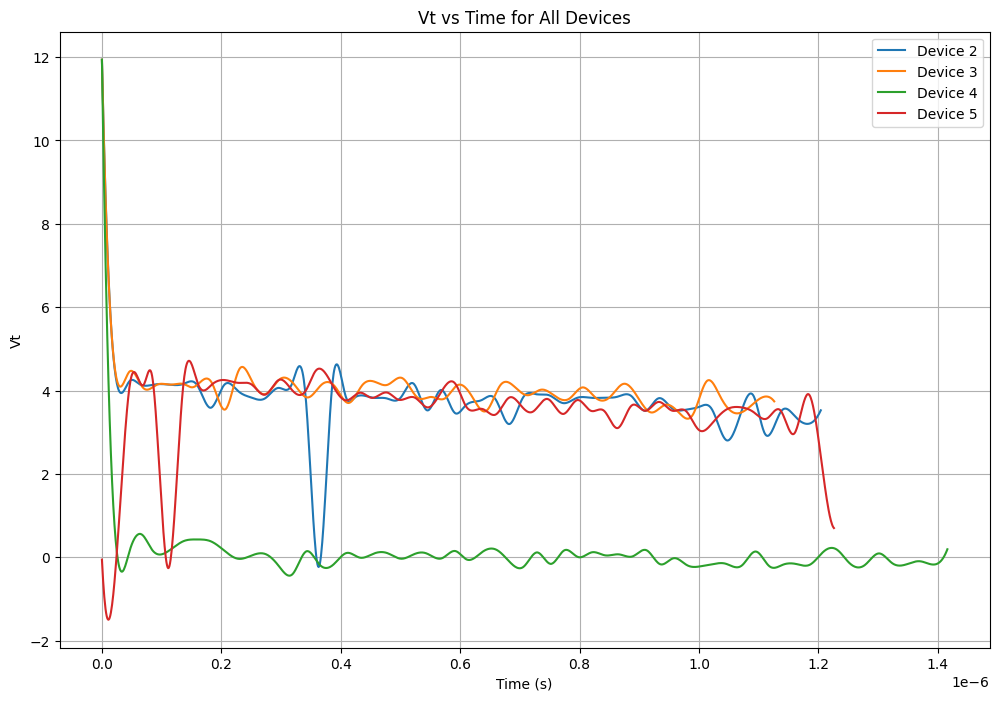

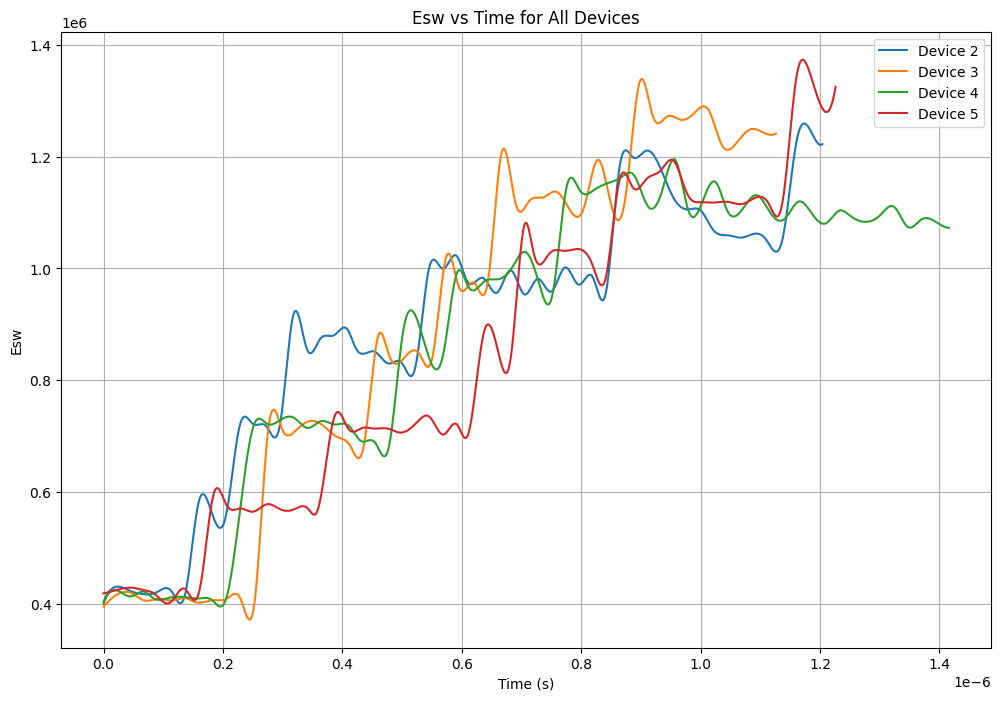

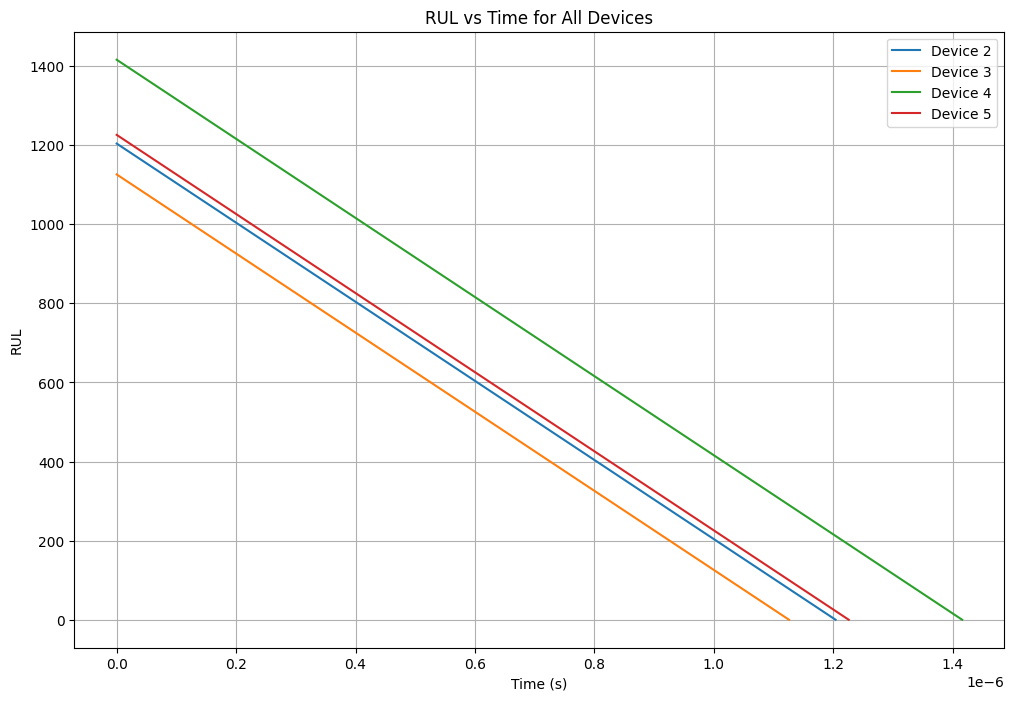

In [4]:
# Plot all features for each device
devices = [device_2_data, device_3_data, device_4_data, device_5_data]
device_names = ["Device 2", "Device 3", "Device 4", "Device 5"]

features = ['Rth', 'Vt', 'Esw', 'RUL']

# Plot eacah feature in a separate subplot for each device
for feature in features:
    plt.figure(figsize=(12, 8))
    for device, name in zip(devices, device_names):
        plt.plot(device['time'], device[feature], label=name)
    plt.title(f"{feature} vs Time for All Devices")
    plt.xlabel("Time (s)")
    plt.ylabel(feature)
    plt.legend()
    plt.grid()
    plt.show()


In [5]:
# Model definitions

class RULModel(torch.nn.Module):
    """ Contains a CNN fed by Esw, an LSTM fed by Rth and Vt, and a cross attention layer that combines the CNN and LSTM outputs to predict RUL. """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int):
        super(RULModel, self).__init__()
        self.cnnconv1=    torch.nn.Conv1d(in_channels=1, out_channels=hidden_size, kernel_size=3, padding=1)
        self.cnnrelu =    torch.nn.ReLU()
        self.cnnpool =  torch.nn.MaxPool1d(1)  # Global average pooling to get a fixed-size output
        self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.attention = torch.nn.MultiheadAttention(embed_dim=hidden_size, num_heads=1, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, esw, rth_vt):
        # CNN branch for Esw
        # esw = esw.permute(0,2,1)  # Add channel dimension; suggested by Gemini
        # esw = esw.unsqueeze(1)  # Add channel dimension
        esw = esw.view(esw.size(0), 1, -1)  # Reshape to (1, 1, seq_len)
        rth_vt = rth_vt.view(rth_vt.size(0), -1, 2)  # Add batch dimension for LSTM

        cnn_out = self.cnnconv1(esw)
        cnn_out = self.cnnrelu(cnn_out)
        cnn_out = self.cnnpool(cnn_out).transpose(1,2) 

        # LSTM branch for Rth and Vt
        lstm_out, _ = self.lstm(rth_vt)
        
        # Cross attention between CNN and LSTM outputs
        attn_output, _ = self.attention(cnn_out, lstm_out,  lstm_out)
        
        # Final RUL prediction
        rul_pred = self.fc(attn_output.squeeze(1))
        
        return rul_pred


In [6]:
# Try to train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_model(model, data_train, data_dev, num_epochs=100, learning_rate=0.001):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    allloss = []

    # move things to the device:
    model.to(device)
    criterion.to(device)
    # data_dev = data_dev.to(device)
    # data_train = [d.to(device) for d in data_train]

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for device_data in data_train:
            esw = torch.tensor([device_data['Esw'].values], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
            rth_vt = torch.tensor(device_data[['Rth', 'Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)
            rul = torch.tensor(device_data['RUL'].values, dtype=torch.float32).to(device)

            optimizer.zero_grad()
            rul_pred = model(esw, rth_vt)
            loss = criterion(rul_pred.squeeze(), rul)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Evaluate on development set
        model.eval()
        with torch.no_grad():
            esw_dev = torch.tensor(data_dev['Esw'].values, dtype=torch.float32).to(device)
            rth_vt_dev = torch.tensor(data_dev[['Rth', 'Vt']].values, dtype=torch.float32).to(device)
            rul_dev = torch.tensor(data_dev['RUL'].values, dtype=torch.float32).to(device)
            rul_pred_dev = model(esw_dev, rth_vt_dev)
            dev_loss = criterion(rul_pred_dev.squeeze(), rul_dev)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(data_train):.4f}, Dev Loss: {dev_loss.item():.4f}")
        allloss += [(train_loss/len(data_train), dev_loss.item())]

    return allloss


Epoch 1/100, Train Loss: 530961.4167, Dev Loss: 483443.7812
Epoch 2/100, Train Loss: 530891.2292, Dev Loss: 483371.2500
Epoch 3/100, Train Loss: 530811.6250, Dev Loss: 483286.7812
Epoch 4/100, Train Loss: 530718.0521, Dev Loss: 483185.9688
Epoch 5/100, Train Loss: 530605.6979, Dev Loss: 483063.2812
Epoch 6/100, Train Loss: 530468.0312, Dev Loss: 482911.7188
Epoch 7/100, Train Loss: 530297.2604, Dev Loss: 482722.6875
Epoch 8/100, Train Loss: 530084.0312, Dev Loss: 482486.1250
Epoch 9/100, Train Loss: 529817.0729, Dev Loss: 482189.9062
Epoch 10/100, Train Loss: 529482.7917, Dev Loss: 481819.0312
Epoch 11/100, Train Loss: 529064.4792, Dev Loss: 481355.8438
Epoch 12/100, Train Loss: 528542.7396, Dev Loss: 480779.7812
Epoch 13/100, Train Loss: 527895.0417, Dev Loss: 480066.9375
Epoch 14/100, Train Loss: 527095.1354, Dev Loss: 479189.8438
Epoch 15/100, Train Loss: 526112.9896, Dev Loss: 478117.5625
Epoch 16/100, Train Loss: 524914.8229, Dev Loss: 476814.7812
Epoch 17/100, Train Loss: 523462.

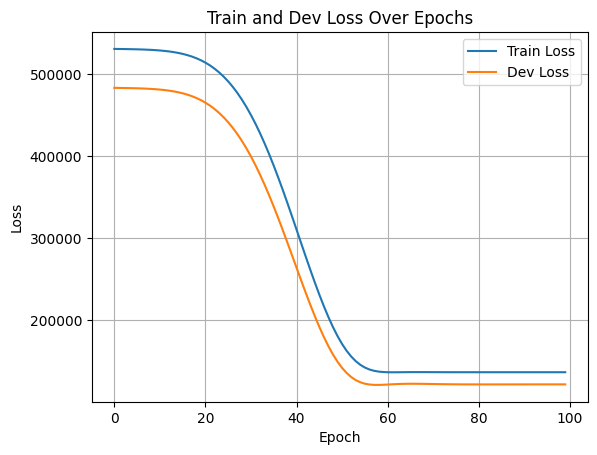

In [8]:
# Train the model...

model = RULModel(input_size=2, hidden_size=32, num_layers=2)
loss = train_model(model, data_train, data_dev, num_epochs=100, learning_rate=0.001)

# plot train, dev loss:
plt.title("Train and Dev Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot([l[0] for l in loss], label="Train Loss")
plt.plot([l[1] for l in loss], label="Dev Loss")
plt.legend()
plt.grid()
plt.show()

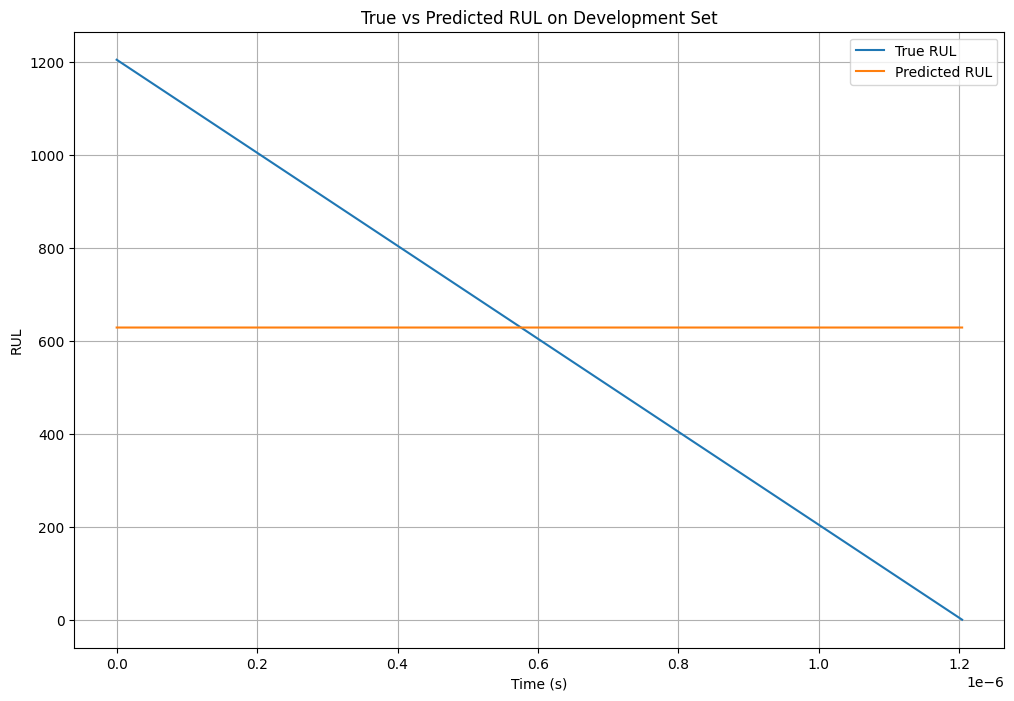

In [9]:
# Plot estimated RUL vs True RUL for the development set

pred_rul = model(torch.tensor(data_dev['Esw'].values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device),
                 torch.tensor(data_dev[['Rth', 'Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)).squeeze().cpu().detach().numpy()
true_rul = data_dev['RUL'].values

plt.figure(figsize=(12, 8))
plt.plot(data_dev['time'], true_rul, label="True RUL")
plt.plot(data_dev['time'], pred_rul, label="Predicted RUL")
plt.title("True vs Predicted RUL on Development Set")
plt.xlabel("Time (s)")
plt.ylabel("RUL")
plt.legend()
plt.grid()
plt.show()